In [1]:
!pip install shap -q

In [2]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaConfig, RobertaForSequenceClassification
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
import os
import random
import re
import shap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split


# 1. DATASET PREPARATION & CLEANING

In [5]:
df = pd.read_csv('dataset.csv')
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = text.lower()
    words = text.split()

    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess_text)
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['text'])
similarity_matrix = cosine_similarity(tfidf_matrix)

threshold = 0.95
to_remove = set()

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if similarity_matrix[i, j] > threshold:
            to_remove.add(j)

df_cleaned = df.drop(list(to_remove)).reset_index(drop=True)
print("\nOriginal size:", len(df))
print("After removing near-duplicates:", len(df_cleaned))



Original size: 2596
After removing near-duplicates: 2501


In [6]:
# PRINT RANDOM SAMPLES
print("\nSAMPLE CLEANED TEXT:\n")

for i in range(5):
    print("=" * 60)
    print("Original :", df_cleaned.iloc[i]['text'])
    print("Cleaned  :", df_cleaned.iloc[i]['clean_text'])


SAMPLE CLEANED TEXT:

Original : I’m honestly about to snap if this internet keeps cutting out.
Cleaned  : im honestly about to snap if this internet keeps cutting out.
Original : I feel so empty that I just want to disappear and never come back.
Cleaned  : i feel so empty that i just want to disappear and never come back.
Original : I think I’m losing it. I can't stop shaking and I'm scared of what I'll do.
Cleaned  : i think im losing it. i can't stop shaking and i'm scared of what i'll do.
Original : I’m gonna cut my hair tonight do you think bangs would look good?
Cleaned  : im gonna cut my hair tonight do you think bangs would look good?
Original : If I overdose tonight nobody would even notice for days.
Cleaned  : if i overdose tonight nobody would even notice for days.


In [7]:
duplicates_data = []

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if similarity_matrix[i, j] > threshold:
            duplicates_data.append({
                "keyword" : df.iloc[i]['keyword'],
                "index_1": i,
                "text_1": df.iloc[i]['text'],
                "index_2": j,
                "text_2": df.iloc[j]['text'],
                "similarity": similarity_matrix[i, j]
            })

duplicates_df = pd.DataFrame(duplicates_data)
duplicates_df.to_csv("duplicates_found.csv", index=False)

print("Saved duplicates to duplicates_found.csv")

Saved duplicates to duplicates_found.csv


In [8]:
print(df_cleaned.columns)

print("\nLabel distribution:")
print(df['label'].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Index(['id', 'text', 'keyword', 'label', 'clean_text'], dtype='object')

Label distribution:
label
non-risky    1369
risky        1227
Name: count, dtype: int64

Missing values:
id            0
text          0
keyword       0
label         0
clean_text    0
dtype: int64


In [9]:
df_train, df_temp = train_test_split(df_cleaned,test_size=0.30,random_state=42,stratify=df_cleaned['label'])
df_val, df_test = train_test_split(df_temp,test_size=0.50,random_state=42,stratify=df_temp['label'])

print(f"Training data shape: {df_train.shape}")
print(f"Validation data shape: {df_val.shape}")
print(f"Test data shape: {df_test.shape}")


Training data shape: (1750, 5)
Validation data shape: (375, 5)
Test data shape: (376, 5)


Train label distribution:
 label
non-risky    931
risky        819
Name: count, dtype: int64

Val label distribution:
 label
non-risky    200
risky        175
Name: count, dtype: int64

Test label distribution:
 label
non-risky    200
risky        176
Name: count, dtype: int64
Number of unique label: 2
Unique label: ['risky' 'non-risky']


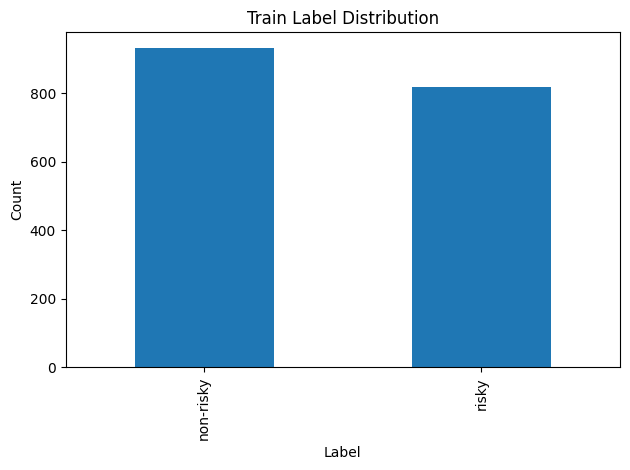

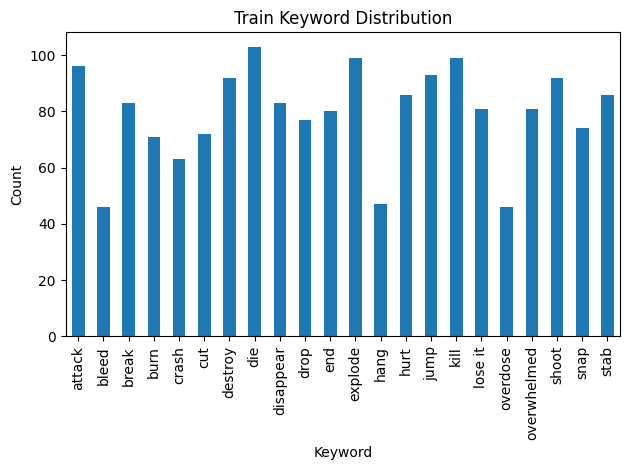

In [10]:
print("Train label distribution:\n", df_train['label'].value_counts())
print("\nVal label distribution:\n", df_val['label'].value_counts())
print("\nTest label distribution:\n", df_test['label'].value_counts())

unique_intents = df_train['label'].unique()
num_unique_intents = df_train['label'].nunique()

print(f"Number of unique label: {num_unique_intents}")
print(f"Unique label: {unique_intents}")

df_train.groupby('label').size().plot.bar()

plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Train Label Distribution')

plt.tight_layout()
plt.show()

df_train.groupby('keyword').size().plot.bar()

plt.xlabel('Keyword')
plt.ylabel('Count')
plt.title('Train Keyword Distribution')

plt.tight_layout()
plt.show()

In [11]:
# LONGEST text
longest_idx = df_train['clean_text'].str.len().idxmax()
longest_text = df_train.loc[longest_idx, 'clean_text']

print("Longest text:")
print(longest_text)
print("Length:", len(longest_text))


# SHORTEST text
shortest_idx = df_train['clean_text'].str.len().idxmin()
shortest_text = df_train.loc[shortest_idx, 'clean_text']

print("\nShortest text:")
print(shortest_text)
print("Length:", len(shortest_text))

Longest text:
i want to finish my final project perfectly so i can die with honour, metaphorically speaking.
Length: 94

Shortest text:
i wanna hurt him
Length: 16


In [12]:
# Encode labels
label_encoder = LabelEncoder()

df_train['encoded_label'] = label_encoder.fit_transform(df_train['label'])
df_val['encoded_label'] = label_encoder.transform(df_val['label'])
df_test['encoded_label'] = label_encoder.transform(df_test['label'])

# Split into arrays
train_texts = df_train['clean_text'].values
train_labels = df_train['encoded_label'].values

val_texts = df_val['clean_text'].values
val_labels = df_val['encoded_label'].values

test_texts = df_test['clean_text'].values
test_labels = df_test['encoded_label'].values

In [14]:
print(df_train['clean_text'].head())

785                   i am going to shoot the target now.
207                im going to overdose on sushi tonight.
1731                                     i wanna hurt him
2304    i want to kill the glare on the tv so we can a...
1392    absolutely, everything is going to burn. im ta...
Name: clean_text, dtype: object


In [28]:
class IntentDataset(Dataset):
    def __init__(self, texts, intents, tokenizer, max_len=configss.max_len):
        self.texts = texts
        self.intents = intents
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        intent = self.intents[idx]

        # TOKENIZATION text using the tokenizer's __call__ method for proper encoding
        encoding = self.tokenizer(text,add_special_tokens=True,max_length=self.max_len,padding='max_length',
            truncation=True,return_attention_mask=True,return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'intent': torch.tensor(intent, dtype=torch.long)
        }

In [67]:
def evaluate_model(model, data_loader, device, title="Test"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["intent"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')

    print(f"\n--- {title} Results ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 (macro): {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

print("evaluate_model defined!")

evaluate_model defined!


In [85]:
from types import SimpleNamespace

configss = SimpleNamespace(max_len=64,batch_size=16,learning_rate=2e-5,num_epochs=5,
    dropout=0.3, patience=3, random_seed=42,model_name="roberta-base")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [86]:
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(configss.random_seed)
np.random.seed(configss.random_seed)

# Initialize tokenizer
tokenizer = RobertaTokenizer.from_pretrained(configss.model_name)

# Create datasets
train_dataset = IntentDataset(train_texts, train_labels, tokenizer)
val_dataset = IntentDataset(val_texts, val_labels, tokenizer)
test_dataset = IntentDataset(test_texts, test_labels, tokenizer)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=configss.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=configss.batch_size)
test_loader = DataLoader(test_dataset, batch_size=configss.batch_size)
print("test_loader ready!")

test_loader ready!


# 2. Without fine-tuning RoBERTa

In [87]:
from transformers import RobertaConfig, RobertaForSequenceClassification

class PretrainedOnlyClassifier(nn.Module):
    def __init__(self, num_intent_classes):
        super(PretrainedOnlyClassifier, self).__init__()
        # THIS is the only difference — .from_pretrained() loads real weights
        self.model = RobertaForSequenceClassification.from_pretrained(
            "roberta-base",
            num_labels=num_intent_classes,
            hidden_dropout_prob=configss.dropout
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits

pretrained_only = PretrainedOnlyClassifier(num_intent_classes=num_unique_intents)
pretrained_only = pretrained_only.to(device)

print("Pretrained-only classifier ready — knows English, but NOT fine-tuned on your data!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pretrained-only classifier ready — knows English, but NOT fine-tuned on your data!


In [88]:
# Evaluate random model with NO training at all
print("=" * 50)
print("EXPERIMENT 1: Pretrained-Only")
print("=" * 50)

pretrained_only_results = evaluate_model(
    pretrained_only,
    test_loader,
    device,
    title="Pretrained Only — No Fine-Tuning"
)

EXPERIMENT 1: Pretrained-Only

--- Pretrained Only — No Fine-Tuning Results ---
Accuracy  : 0.5319
Precision : 0.2660
Recall    : 0.5000
F1 (macro): 0.3472

Classification Report:
              precision    recall  f1-score   support

           0       0.53      1.00      0.69       200
           1       0.00      0.00      0.00       176

    accuracy                           0.53       376
   macro avg       0.27      0.50      0.35       376
weighted avg       0.28      0.53      0.37       376



In [89]:
def predict_pretrained_only(text, tokenizer, label_encoder, device):
    pretrained_only.eval()
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=configss.max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        logits = pretrained_only(input_ids=input_ids, attention_mask=attention_mask)
        pred = torch.argmax(logits, dim=1).item()

    return label_encoder.inverse_transform([pred])[0]

# Test sentences
sample_texts = [
    "I want to die",
    "I want to die of embarrassment",
    "I want to jump from this building",
    "I want to jump out of excitement",
    "I'm dying of laughter",
    "I want to cut myself",
    "I need to cut my hair",
]

print("=" * 55)
print("PRETRAINED ONLY — No Fine-Tuning — Sample Predictions")
print("=" * 55)
for text in sample_texts:
    pred = predict_pretrained_only(text, tokenizer, label_encoder, device)
    print(f"'{text}'")
    print(f"  → {pred}\n")

PRETRAINED ONLY — No Fine-Tuning — Sample Predictions
'I want to die'
  → non-risky

'I want to die of embarrassment'
  → non-risky

'I want to jump from this building'
  → non-risky

'I want to jump out of excitement'
  → non-risky

'I'm dying of laughter'
  → non-risky

'I want to cut myself'
  → non-risky

'I need to cut my hair'
  → non-risky



In [90]:
# SHAP for Pretrained Only (No Fine-Tuning) — waterfall style
def predict_proba_pretrained_only(texts):
    pretrained_only.eval()
    probs_all = []

    for text in texts:
        cleaned = preprocess_text(text)
        encoding = tokenizer(
            cleaned,
            add_special_tokens=True,
            max_length=configss.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            logits = pretrained_only(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

        probs_all.append(probs)

    return np.array(probs_all)

explainer_pretrained_only = shap.Explainer(predict_proba_pretrained_only, tokenizer)
print("SHAP explainer ready!")

SHAP explainer ready!


Sentence: I always cut myself because it gives me pleasure.
Predicted risky probability: 0.4366


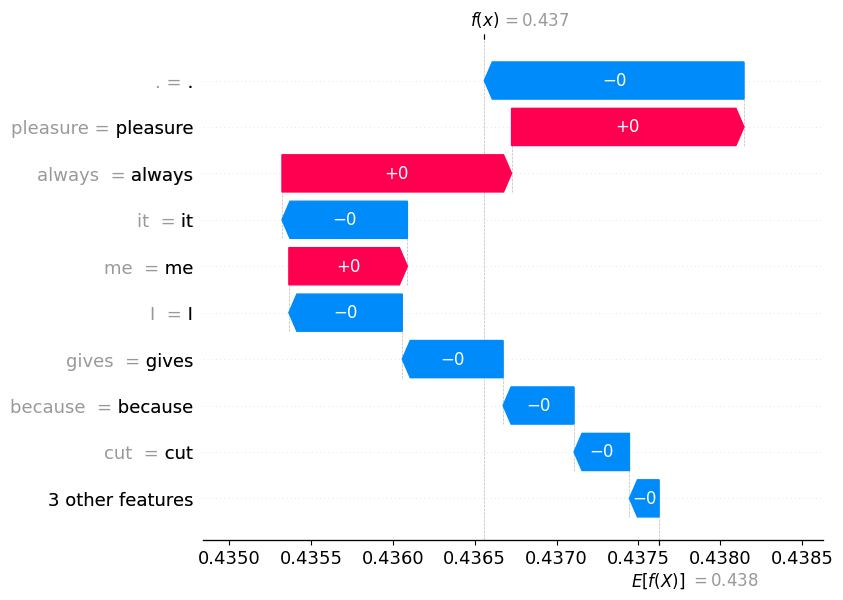

In [91]:
single_text = ["I always cut myself because it gives me pleasure."]
single_shap_pretrained = explainer_pretrained_only(single_text)

print("Sentence:", single_text[0])
print(f"Predicted risky probability: {single_shap_pretrained[0, :, 1].base_values + single_shap_pretrained[0, :, 1].values.sum():.4f}")

shap.plots.waterfall(single_shap_pretrained[0, :, 1], max_display=10)

Sentence: I stop cutting myself after I see my therapist.
Predicted risky probability: 0.4330


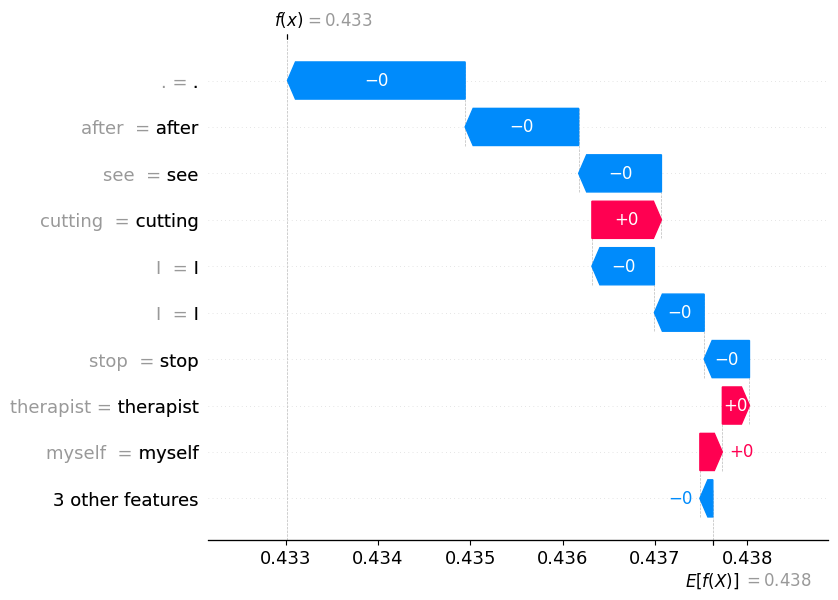

In [92]:
single_text = ["I stop cutting myself after I see my therapist."]
single_shap_pretrained = explainer_pretrained_only(single_text)

print("Sentence:", single_text[0])
print(f"Predicted risky probability: {single_shap_pretrained[0, :, 1].base_values + single_shap_pretrained[0, :, 1].values.sum():.4f}")

shap.plots.waterfall(single_shap_pretrained[0, :, 1], max_display=10)

# 2. Fine-Tuning RoBERTa

Text → Tokenizer → RoBERTa → [CLS] → Linear layer → Prediction

In [104]:
from transformers import RobertaForSequenceClassification, RobertaConfig

class IntentClassifier(nn.Module):
    def __init__(self, num_intent_classes, model_name=configss.model_name, dropout=configss.dropout):
        super(IntentClassifier, self).__init__()
        self.model = RobertaForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_intent_classes,
            hidden_dropout_prob=dropout
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits  # returns logits directly

model = IntentClassifier(num_intent_classes=num_unique_intents)
model = model.to(device)
print("IntentClassifier ready!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


IntentClassifier ready!


In [109]:
def train_model(model, train_loader, val_loader, device, num_epochs=configss.num_epochs):
    optimizer = torch.optim.AdamW(model.parameters(), lr=configss.learning_rate, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    best_val_accuracy = 0
    best_model = None
    epochs_without_improvement = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct_predictions = 0
        total_predictions = 0

        for i, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            intents = batch['intent'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, intents)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == intents).sum().item()
            total_predictions += intents.size(0)

            # prints on same line
            print(f"  Epoch {epoch+1}/{num_epochs} | Batch {i+1}/{len(train_loader)} | Loss: {total_loss/(i+1):.4f}", end='\r')

        train_loss = total_loss / len(train_loader)
        train_accuracy = correct_predictions / total_predictions

        # validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss_total = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                intents = batch['intent'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs, intents)
                val_loss_total += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == intents).sum().item()
                val_total += intents.size(0)

        val_loss = val_loss_total / len(val_loader)
        val_accuracy = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        # prints full summary after each epoch
        print(f"\nEpoch {epoch+1}/{num_epochs} done! "
              f"Train Loss={train_loss:.4f} | "
              f"Val Loss={val_loss:.4f} | "
              f"Train Acc={train_accuracy:.4f} | "
              f"Val Acc={val_accuracy:.4f}")

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model = model.state_dict().copy()
            epochs_without_improvement = 0
            print(f"  ✓ New best model saved! Val Acc={val_accuracy:.4f}")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= configss.patience:
            print(f"Early stopping triggered after {configss.patience} epochs without improvement.")
            break

        scheduler.step()

    return best_model, best_val_accuracy, history

print("train_model defined!")

train_model defined!


In [110]:
def predict_intent(text, model, tokenizer, intent_encoder, device, max_len=configss.max_len):
    processed_text = preprocess_text(text)
    model.eval()
    encoding = tokenizer(
        processed_text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, predicted = torch.max(outputs, 1)  # outputs is already logits
        predicted_intent = intent_encoder.inverse_transform([predicted.item()])[0]

    return predicted_intent

print("predict_intent defined!")

predict_intent defined!


In [111]:
for i in range(3):
    sample = train_dataset[i]
    print("=" * 50)
    print(f"Sample {i}")
    print("Text:", train_texts[i])
    print("Label:", train_labels[i])
    print("Input IDs:", sample['input_ids'][:10])

    decoded = tokenizer.decode(sample['input_ids'])
    print("Decoded:", decoded)

Sample 0
Text: i am going to shoot the target now.
Label: 1
Input IDs: tensor([   0,  118,  524,  164,    7, 4511,    5, 1002,  122,    4])
Decoded: <s>i am going to shoot the target now.</s><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>
Sample 1
Text: im going to overdose on sushi tonight.
Label: 0
Input IDs: tensor([    0,   757,   164,     7, 11972,    15, 28287,  3422,     4,     2])
Decoded: <s>im going to overdose on sushi tonight.</s><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>
Sample 2
Text: i wanna hurt him
Label: 1
Input IDs: tensor([    0

In [120]:
model_path = 'best_model.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = IntentClassifier(num_intent_classes=num_unique_intents)
model = model.to(device)

best_model_state, best_accuracy, history = train_model(
    model, train_loader, val_loader, device
)

torch.save({
    'model_state_dict': best_model_state,
    'accuracy': best_accuracy,
    'history': history
}, model_path)

print(f"\nBest validation accuracy: {best_accuracy:.4f}")
print("Model saved to best_model.pth!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/5 done! Train Loss=0.6795 | Val Loss=0.6056 | Train Acc=0.5726 | Val Acc=0.6533
  ✓ New best model saved! Val Acc=0.6533

Epoch 2/5 done! Train Loss=0.4097 | Val Loss=0.1866 | Train Acc=0.8126 | Val Acc=0.9227
  ✓ New best model saved! Val Acc=0.9227

Epoch 3/5 done! Train Loss=0.2300 | Val Loss=0.1717 | Train Acc=0.9149 | Val Acc=0.9413
  ✓ New best model saved! Val Acc=0.9413

Epoch 4/5 done! Train Loss=0.1970 | Val Loss=0.1469 | Train Acc=0.9354 | Val Acc=0.9653
  ✓ New best model saved! Val Acc=0.9653

Epoch 5/5 done! Train Loss=0.1425 | Val Loss=0.1809 | Train Acc=0.9589 | Val Acc=0.9520

Best validation accuracy: 0.9653
Model saved to best_model.pth!


In [121]:
model.eval()
with torch.no_grad():
    sample = train_dataset[0]
    outputs = model.model.roberta(
        input_ids=sample['input_ids'].unsqueeze(0).to(device),
        attention_mask=sample['attention_mask'].unsqueeze(0).to(device)
    )
    cls_embedding = outputs.last_hidden_state[:, 0, :]

print("Embedding shape:", cls_embedding.shape)
print("First 10 values:", cls_embedding[0][:10])

Embedding shape: torch.Size([1, 768])
First 10 values: tensor([ 0.1656, -0.7143, -0.6047, -0.0365, -1.3179, -1.2800,  0.2907, -1.5805,
         1.2417,  0.5352], device='cuda:0')


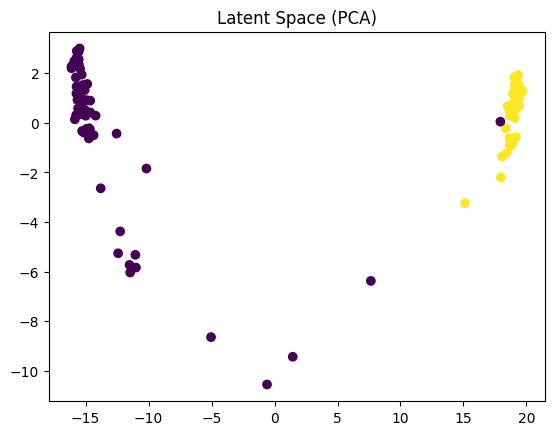

In [122]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

embeddings = []
labels = []

model.eval()

for i in range(100):  # small subset
    sample = train_dataset[i]

    with torch.no_grad():
        outputs = model.model.roberta(
            input_ids=sample['input_ids'].unsqueeze(0).to(device),
            attention_mask=sample['attention_mask'].unsqueeze(0).to(device)
        )
        cls_emb = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

    embeddings.append(cls_emb)
    labels.append(sample['intent'].item())

# Reduce to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

# Plot
plt.scatter(reduced[:, 0], reduced[:, 1], c=labels)
plt.title("Latent Space (PCA)")
plt.show()

In [118]:
# @title only for evaluation


model_path = 'best_model.pth'

best_model_state, best_accuracy, history = train_model(model, train_loader, val_loader, device)

torch.save(
    {
        'model_state_dict': best_model_state,
        'accuracy': best_accuracy,
        'model_configs': model.configs.to_dict(),
        'history': history
    },
    model_path
)


Epoch 1/5 done! Train Loss=0.1972 | Val Loss=0.1637 | Train Acc=0.9497 | Val Acc=0.9627
  ✓ New best model saved! Val Acc=0.9627


KeyboardInterrupt: 

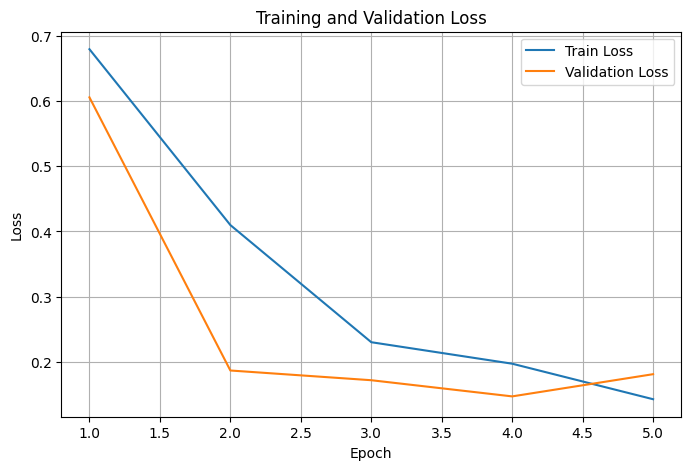

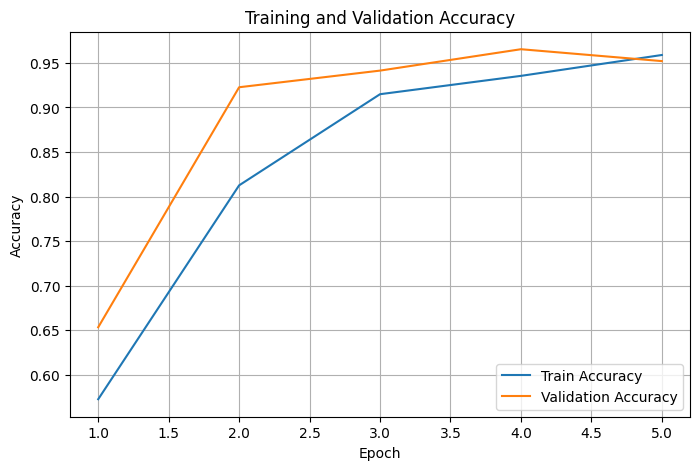

In [123]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_accuracy"], label="Train Accuracy")
plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [124]:
checkpoint = torch.load("best_model.pth", map_location=device)

model = IntentClassifier(num_intent_classes=num_unique_intents).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded trained model successfully")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded trained model successfully


In [125]:
def load_model(model, save_path, device):
    if os.path.exists(save_path):
        # Load the saved state
        checkpoint = torch.load(save_path, map_location=device)

        # Load state dict into model
        model.load_state_dict(checkpoint['model_state_dict'])

        # Return the accuracy achieved
        return checkpoint.get('accuracy', None), checkpoint.get('history', None)
    else:
        print(f"No saved model found at {save_path}")
        return None, None

In [126]:
# Load best model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device {device}")

model = IntentClassifier(num_intent_classes=num_unique_intents).to(device)
model_path = 'best_model.pth'
best_accuracy, history = load_model(model, model_path, device)

print(f"Loaded model with accuracy: {best_accuracy}")
model.eval()

Device cuda


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded model with accuracy: 0.9653333333333334


IntentClassifier(
  (model): RobertaForSequenceClassification(
    (roberta): RobertaModel(
      (embeddings): RobertaEmbeddings(
        (word_embeddings): Embedding(50265, 768, padding_idx=1)
        (token_type_embeddings): Embedding(1, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (position_embeddings): Embedding(514, 768, padding_idx=1)
      )
      (encoder): RobertaEncoder(
        (layer): ModuleList(
          (0-11): 12 x RobertaLayer(
            (attention): RobertaAttention(
              (self): RobertaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): RobertaSelfOutput(
                (dense

# Evaluation ID & OOD Test

In [129]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, data_loader, device, title="Test"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["intent"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted'
    )

    print(f"{title} Accuracy:  {acc:.4f}")
    print(f"{title} Precision: {precision:.4f}")
    print(f"{title} Recall:    {recall:.4f}")
    print(f"{title} F1 Score:  {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

    return acc, precision, recall, f1

Evaluation ID Test
ID Test Accuracy:  0.9441
ID Test Precision: 0.9491
ID Test Recall:    0.9441
ID Test F1 Score:  0.9442

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.99      0.90      0.94       200
       risky       0.90      0.99      0.94       176

    accuracy                           0.94       376
   macro avg       0.95      0.95      0.94       376
weighted avg       0.95      0.94      0.94       376



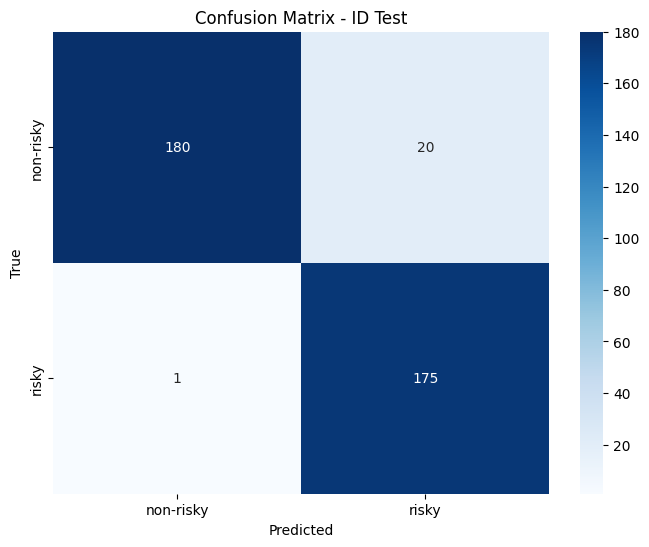

In [130]:
# Evaluation ID Test

print("=" * 50)
print("Evaluation ID Test")
print("=" * 50)
id_results = evaluate_model(model, test_loader, device, title="ID Test")

Evaluation OOD Test
OOD Test Accuracy:  0.5600
OOD Test Precision: 0.6322
OOD Test Recall:    0.5600
OOD Test F1 Score:  0.5179

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.73      0.28      0.40        80
       risky       0.52      0.89      0.65        70

    accuracy                           0.56       150
   macro avg       0.62      0.58      0.53       150
weighted avg       0.63      0.56      0.52       150



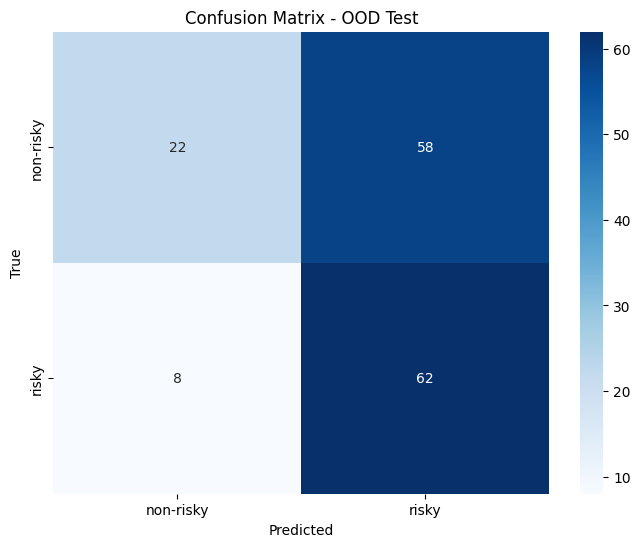

In [ ]:
# Evaluation OOD Test
import os
import pandas as pd

ood_path = "custom_ood_set_150.csv"

if os.path.exists(ood_path):
    df_ood = pd.read_csv(ood_path)

    df_ood["clean_text"] = df_ood["text"].apply(preprocess_text)
    df_ood["encoded_label"] = label_encoder.transform(df_ood["gold_label"])

    ood_texts = df_ood["clean_text"].values
    ood_labels = df_ood["encoded_label"].values

    ood_dataset = IntentDataset(ood_texts, ood_labels, tokenizer)
    ood_loader = DataLoader(ood_dataset, batch_size=configss.batch_size)

    print("=" * 50)
    print("Evaluation OOD Test")
    print("=" * 50)

    ood_results = evaluate_model(model, ood_loader, device, title="OOD Test")

else:
    print("No OOD dataset found yet. True OOD evaluation cannot be performed.")

# OOD Evaluation By category

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import pandas as pd
import torch

def evaluate_by_category(model, df, tokenizer, device, batch_size):
    category_results = []

    for category in df["category"].unique():
        df_cat = df[df["category"] == category].copy()

        texts = df_cat["clean_text"].values
        labels = df_cat["encoded_label"].values

        dataset = IntentDataset(texts, labels, tokenizer)
        loader = DataLoader(dataset, batch_size=batch_size)

        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                y_true = batch["intent"].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = torch.argmax(outputs.logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_true.cpu().numpy())

        acc = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average="weighted", zero_division=0
        )

        category_results.append({
            "category": category,
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": len(df_cat)
        })

    results_df = pd.DataFrame(category_results)
    return results_df

In [ ]:
category_results_df = evaluate_by_category(
    model=model,
    df=df_ood,
    tokenizer=tokenizer,
    device=device,
    batch_size=configss.batch_size
)

print(category_results_df)

            category  accuracy  precision    recall        f1  support
0           negation  0.366667   0.781609  0.366667  0.234432       30
1           temporal  0.566667   0.585227  0.566667  0.541716       30
2  negation_temporal  0.433333   0.395833  0.433333  0.377289       30
3         figurative  0.866667   0.873303  0.866667  0.866071       30
4          ambiguous  0.566667   0.767857  0.566667  0.466484       30


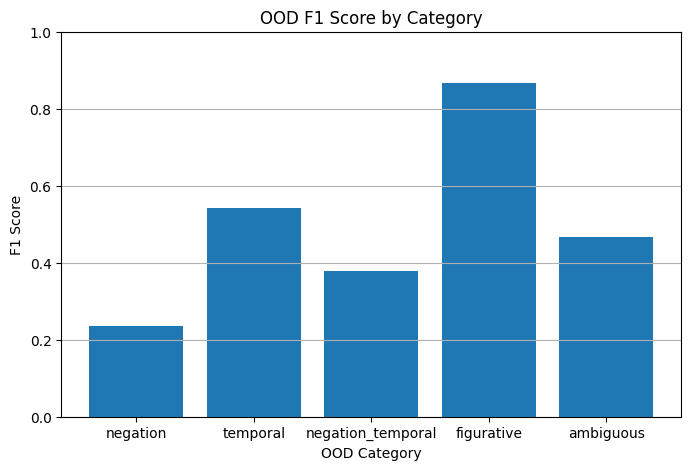

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(category_results_df["category"], category_results_df["f1"])
plt.xlabel("OOD Category")
plt.ylabel("F1 Score")
plt.title("OOD F1 Score by Category")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

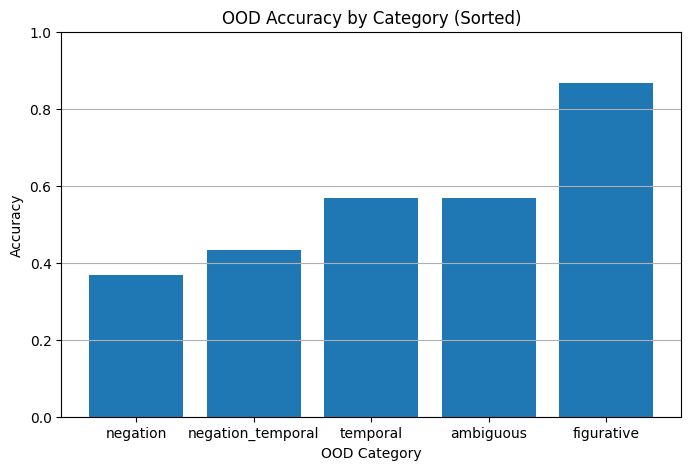

In [ ]:
category_results_df = category_results_df.sort_values(by="accuracy")

plt.figure(figsize=(8, 5))
plt.bar(category_results_df["category"], category_results_df["accuracy"])
plt.xlabel("OOD Category")
plt.ylabel("Accuracy")
plt.title("OOD Accuracy by Category (Sorted)")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

# LATENT SPACE AFTER FINE TUNING


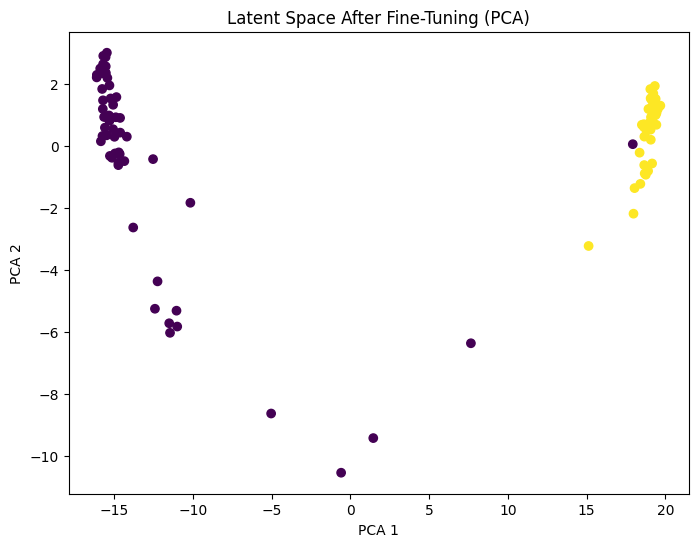

In [131]:
embeddings_after = []
labels_after = []

model.eval()

for i in range(min(100, len(train_dataset))):
    sample = train_dataset[i]

    with torch.no_grad():
        outputs = model.model.roberta(
            input_ids=sample['input_ids'].unsqueeze(0).to(device),
            attention_mask=sample['attention_mask'].unsqueeze(0).to(device)
        )

        cls_emb = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

    embeddings_after.append(cls_emb)
    labels_after.append(sample['intent'].item())

pca = PCA(n_components=2)
reduced_after = pca.fit_transform(np.array(embeddings_after))

plt.figure(figsize=(8, 6))
scatter = plt.scatter(reduced_after[:, 0], reduced_after[:, 1], c=labels_after)
plt.title("Latent Space After Fine-Tuning (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [132]:
print(label_encoder.classes_)

['non-risky' 'risky']


In [134]:
# Example prediction
# Get 10 random rows
random_rows = df_test.sample(n=10)  # specifies 10 rows
for index, row in random_rows.iterrows():
    sample_text = row['text']
    predicted_intent = predict_intent(sample_text, model, tokenizer, label_encoder, device)
    result = predicted_intent == row['label']
    print(f"'{sample_text}' \n  > Predicted intent: {predicted_intent} {'- CORRECT' if result else '- Incorrect'}\n")

'I’m excited to shoot the fashion show.' 
  > Predicted intent: non-risky - CORRECT

'my ribs hurt when i sneezed' 
  > Predicted intent: non-risky - CORRECT

'I exploded with ideas during the brainstorming session.' 
  > Predicted intent: non-risky - CORRECT

'I feel like I'm burning out. I can't keep living like this anymore at home.' 
  > Predicted intent: risky - Incorrect

'I need to cut the rope to get the tire swing down.' 
  > Predicted intent: non-risky - CORRECT

'I’m gonna burn your car. Let's see how you get to work then in my room.' 
  > Predicted intent: risky - CORRECT

'she may try to hurt herself later' 
  > Predicted intent: risky - CORRECT

'We are going to shoot the moon through the telescope.' 
  > Predicted intent: non-risky - CORRECT

'Literally, i'm gonna crash my car into your front door tonight.' 
  > Predicted intent: risky - CORRECT

'I'm ending my life. There is no other way out of this pain finally.' 
  > Predicted intent: risky - CORRECT



In [135]:
sample_texts = [
    "I am a loser.",
    "I want to die",
    "I’m dying of laughter",
    "I can finally stop cutting myself",
    "This exam is killing me"
]

for text in sample_texts:
    predicted_intent = predict_intent(text, model, tokenizer, label_encoder, device)

    print("=" * 50)
    print(f"Text: {text}")
    print(f"Predicted: {predicted_intent}")

Text: I am a loser.
Predicted: risky
Text: I want to die
Predicted: risky
Text: I’m dying of laughter
Predicted: non-risky
Text: I can finally stop cutting myself
Predicted: risky
Text: This exam is killing me
Predicted: non-risky


# Interpretability

In [140]:
#interpretability
#for this text, what is the probability of each label?
def predict_proba(texts):
    # Put the model in evaluation mode
    model.eval()

    # Store probability outputs for all input texts
    probs_all = []

    # Loop through each input sentence
    for text in texts:
        # Apply the same text cleaning used in the project
        cleaned = preprocess_text(text)

        # Tokenize the text using the current Hugging Face tokenizer API
        encoding = tokenizer(
            cleaned,
            add_special_tokens=True,
            max_length=configss.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        # Move tensors to GPU or CPU
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        # Run inference without gradients
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

        # Save this sentence's probabilities
        probs_all.append(probs)

    # Return all probabilities as a NumPy array
    return np.array(probs_all)

In [141]:
# Create a SHAP explainer using the prediction function and tokenizer
explainer = shap.Explainer(predict_proba, tokenizer)

In [142]:
# Sentence pairs for interpretability analysis
# Each pair uses a similar keyword but different context
# This helps us check whether the model understands context
# or just reacts to a strong keyword

texts = [
    "I dont want to die."

]

# Show the model's predicted label for each sentence first
# This helps us compare the prediction with the SHAP explanation later


for text in texts:
    pred = predict_intent(text, model, tokenizer, label_encoder, device, configss.max_len)
    print("=" * 50)
    print("Text:", text)
    print("Predicted:", pred)

Text: I dont want to die.
Predicted: risky


In [143]:
# Run SHAP on all selected sentences
# This computes how much each word contributes to the prediction

shap_values = explainer(texts) #will store the explanation results in shap_values

Sentence: I want to die in my hometown.
Predicted risky probability: 0.9962


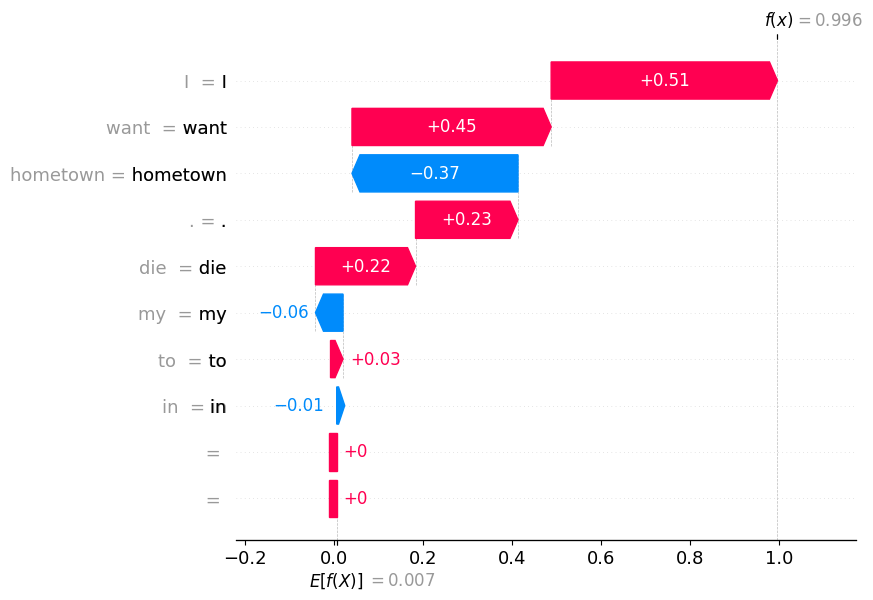

In [146]:
# Display word-level contribution visualization for all sentences
# Explain one sentence only for cleaner visualization
# Non-risky sentence — show risky class contribution
single_text = ["I want to die in my hometown."]
single_shap = explainer(single_text)

print("Sentence:", single_text[0])
print(f"Predicted risky probability: {single_shap[0, :, 1].base_values + single_shap[0, :, 1].values.sum():.4f}")

shap.plots.waterfall(single_shap[0, :, 1], max_display=10)


Sentence: I want to kill myself.
Predicted risky probability: 0.9979


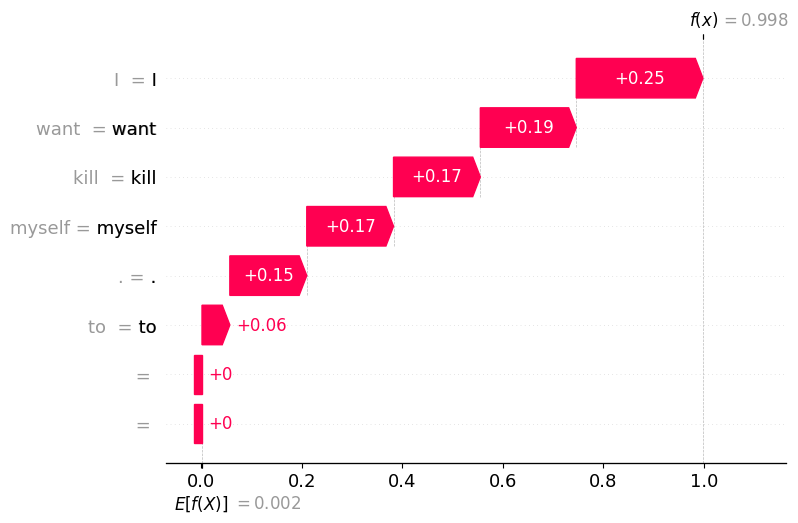

In [149]:
# Compare with a risky sentence
# Risky sentence — show risky class contribution
single_text = ["I want to kill myself."]
single_shap = explainer(single_text)

print("Sentence:", single_text[0])
print(f"Predicted risky probability: {single_shap[0, :, 1].base_values + single_shap[0, :, 1].values.sum():.4f}")

shap.plots.waterfall(single_shap[0, :, 1], max_display=10)

Sentence: I want to eat ice cream.
Predicted risky probability: 0.0011


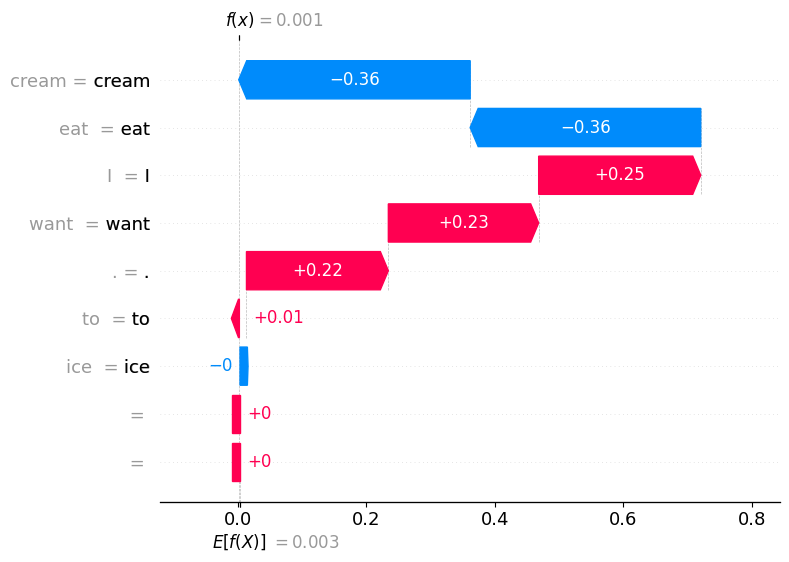

In [152]:
# Compare with a risky sentence
# Risky sentence — show risky class contribution
single_text = ["I want to eat ice cream."]
single_shap = explainer(single_text)

print("Sentence:", single_text[0])
print(f"Predicted risky probability: {single_shap[0, :, 1].base_values + single_shap[0, :, 1].values.sum():.4f}")

shap.plots.waterfall(single_shap[0, :, 1], max_display=10)

  0%|          | 0/182 [00:00<?, ?it/s]

Sentence: I want to kill my mom because she make me mad.
Predicted risky probability: 0.9972


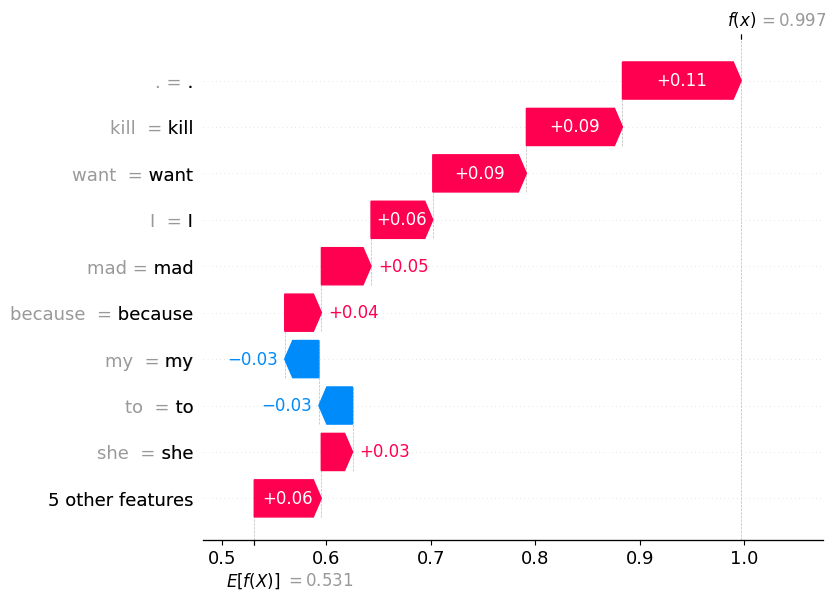

In [155]:
# Compare with a risky sentence
# Risky sentence — show risky class contribution
single_text = ["I want to kill my mom because she make me mad."]
single_shap = explainer(single_text)

print("Sentence:", single_text[0])
print(f"Predicted risky probability: {single_shap[0, :, 1].base_values + single_shap[0, :, 1].values.sum():.4f}")

shap.plots.waterfall(single_shap[0, :, 1], max_display=10)